## 1) Import Lib

In [1]:
from pathlib import Path
import warnings
import json
import sys
import platform

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import sklearn

warnings.filterwarnings("ignore")

## 2) Data

In [2]:
PROJECT_ROOT = Path(r"D:/Study/DATN/hand_gesture_windows_control")

DATA_DIR = PROJECT_ROOT.joinpath("data", "processed", "static")
MODEL_DIR = PROJECT_ROOT.joinpath("models", "checkpoints")
REPORT_DIR = PROJECT_ROOT.joinpath("models", "reports", "model_comparison_ipynb")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR.joinpath("train_static_v1.csv")
VAL_CSV = DATA_DIR.joinpath("val_static_v1.csv")
TEST_CSV = DATA_DIR.joinpath("test_static_v1.csv")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)

PROJECT_ROOT = D:\Study\DATN\hand_gesture_windows_control
TRAIN_CSV = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\train_static_v1.csv
VAL_CSV   = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\val_static_v1.csv
TEST_CSV  = D:\Study\DATN\hand_gesture_windows_control\data\processed\static\test_static_v1.csv


## 2. Load dữ liệu

In [3]:
FEATURE_COLS = [f"f{i}" for i in range(63)]

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

X_train = train_df[FEATURE_COLS].values
y_train = train_df["label"].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df["label"].values

X_test = test_df[FEATURE_COLS].values
y_test = test_df["label"].values

labels = sorted(set(y_train) | set(y_val) | set(y_test))

print("Train:", X_train.shape, len(y_train))
print("Val:  ", X_val.shape, len(y_val))
print("Test: ", X_test.shape, len(y_test))
print("Labels:", labels)

Train: (2974, 63) 2974
Val:   (1018, 63) 1018
Test:  (1051, 63) 1051
Labels: ['fist', 'no_gesture', 'open_palm', 'pinch', 'point', 'two_fingers']


In [4]:
X_train[:1]

array([[ 0.        ,  0.        ,  0.        , -0.17889526, -0.08061599,
        -0.03870525, -0.34192833, -0.37298369, -0.04768515, -0.4085187 ,
        -0.63542175, -0.06600151, -0.43489689, -0.85301846, -0.07523307,
        -0.26030904, -0.7398724 ,  0.04131817, -0.32479832, -0.9281792 ,
        -0.04616209, -0.2983526 , -0.70436138, -0.10739975, -0.25641474,
        -0.49527523, -0.13280408, -0.15123761, -0.78122056,  0.02394647,
        -0.21900167, -0.97361797, -0.06408107, -0.19447821, -0.68342984,
        -0.09579583, -0.15198088, -0.46513748, -0.09030399, -0.02685988,
        -0.7749182 , -0.0107263 , -0.09634602, -0.97444093, -0.10260185,
        -0.08695573, -0.67963016, -0.08634921, -0.05708436, -0.46494997,
        -0.0452048 ,  0.10901178, -0.72439402, -0.04988238,  0.03497037,
        -0.90598774, -0.11632267,  0.01871683, -0.69728148, -0.09516854,
         0.03629063, -0.52095473, -0.05747838]])

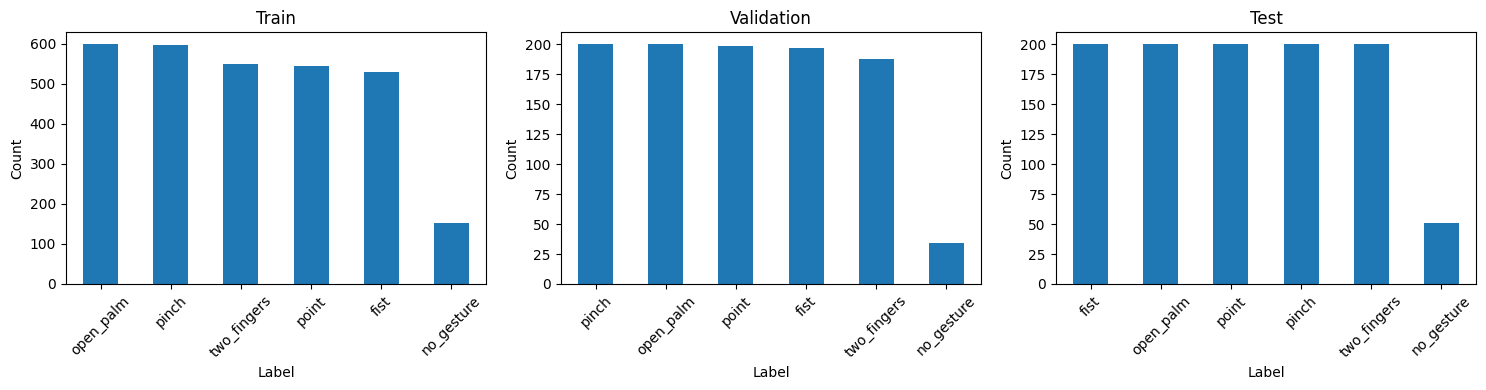

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_df["label"].value_counts().plot(kind="bar", ax=axes[0], title="Train")
val_df["label"].value_counts().plot(kind="bar", ax=axes[1], title="Validation")
test_df["label"].value_counts().plot(kind="bar", ax=axes[2], title="Test")

for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [6]:
display(train_df["label"].value_counts().rename("train_count").to_frame())
display(val_df["label"].value_counts().rename("val_count").to_frame())
display(test_df["label"].value_counts().rename("test_count").to_frame())

,train_count
label,
open_palm,599
pinch,597
two_fingers,549
point,545
fist,531
no_gesture,153


,val_count
label,
pinch,200
open_palm,200
point,199
fist,197
two_fingers,188
no_gesture,34


,test_count
label,
fist,200
open_palm,200
point,200
pinch,200
two_fingers,200
no_gesture,51


## 3. Train Model (SVM, logistic reg, KNN, Random fr, mlp)

In [7]:
models = {
    "svm_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", class_weight="balanced", probability=True))
    ]),
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "knn": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance"
        ))
    ]),
    "random_forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    # "mlp": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("clf", MLPClassifier(
    #         hidden_layer_sizes=(128, 64),
    #         activation="relu",
    #         solver="adam",
    #         alpha=1e-4,
    #         batch_size=64,
    #         learning_rate_init=1e-3,
    #         max_iter=300,
    #         early_stopping=True,
    #         validation_fraction=0.1,
    #         random_state=42
    #     ))
    # ]),
}

list(models.keys())

['svm_rbf', 'logistic_regression', 'knn', 'random_forest']

In [8]:
# hàm đánh giá model

def evaluate_model(model_name, model, X_val, y_val, X_test, y_test, labels):
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    val_macro_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    test_macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

    val_weighted_f1 = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

    val_report = classification_report(
        y_val, y_val_pred, labels=labels, digits=4, zero_division=0
    )
    test_report = classification_report(
        y_test, y_test_pred, labels=labels, digits=4, zero_division=0
    )

    val_cm = confusion_matrix(y_val, y_val_pred, labels=labels)
    test_cm = confusion_matrix(y_test, y_test_pred, labels=labels)

    return {
        "model_name": model_name,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "val_macro_f1": val_macro_f1,
        "test_macro_f1": test_macro_f1,
        "val_weighted_f1": val_weighted_f1,
        "test_weighted_f1": test_weighted_f1,
        "val_report": val_report,
        "test_report": test_report,
        "val_cm": val_cm,
        "test_cm": test_cm,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }

In [9]:
results = {}
summary_rows = []

for model_name, model in models.items():
    print("=" * 80)
    print("Training:", model_name)

    model.fit(X_train, y_train)

    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        labels=labels,
    )

    results[model_name] = {
        "model": model,
        **result
    }

    summary_rows.append({
        "model": model_name,
        "val_accuracy": round(result["val_acc"], 6),
        "test_accuracy": round(result["test_acc"], 6),
        "val_macro_f1": round(result["val_macro_f1"], 6),
        "test_macro_f1": round(result["test_macro_f1"], 6),
        "val_weighted_f1": round(result["val_weighted_f1"], 6),
        "test_weighted_f1": round(result["test_weighted_f1"], 6),
    })

    print("Validation Accuracy :", round(result["val_acc"], 4))
    print("Test Accuracy       :", round(result["test_acc"], 4))
    print("Validation Macro F1 :", round(result["val_macro_f1"], 4))
    print("Test Macro F1       :", round(result["test_macro_f1"], 4))

Training: svm_rbf
Validation Accuracy : 0.9794
Test Accuracy       : 0.9734
Validation Macro F1 : 0.9803
Test Macro F1       : 0.9425
Training: logistic_regression
Validation Accuracy : 0.9853
Test Accuracy       : 0.9705
Validation Macro F1 : 0.9853
Test Macro F1       : 0.9399
Training: knn
Validation Accuracy : 0.9175
Test Accuracy       : 0.9267
Validation Macro F1 : 0.9295
Test Macro F1       : 0.8574
Training: random_forest
Validation Accuracy : 0.9676
Test Accuracy       : 0.9562
Validation Macro F1 : 0.9723
Test Macro F1       : 0.9209


## 4. Kết quả train

In [10]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["test_macro_f1", "val_macro_f1", "test_accuracy", "val_accuracy"],
    ascending=False
).reset_index(drop=True)

summary_df

,model,val_accuracy,test_accuracy,val_macro_f1,test_macro_f1,val_weighted_f1,test_weighted_f1
0,svm_rbf,0.979371,0.973359,0.980291,0.942464,0.979350,0.971062
1,logistic_regression,0.985265,0.970504,0.985335,0.939921,0.985259,0.968158
2,random_forest,0.967583,0.956232,0.972301,0.920896,0.967580,0.953303
3,knn,0.917485,0.926736,0.929509,0.857365,0.917132,0.917844


In [11]:
best_row = summary_df.iloc[0]
BEST_MODEL_NAME = best_row["model"]

print("=== BEST MODEL ===")
print(best_row)
print("\nChosen model:", BEST_MODEL_NAME)

=== BEST MODEL ===
model                svm_rbf
val_accuracy        0.979371
test_accuracy       0.973359
val_macro_f1        0.980291
test_macro_f1       0.942464
val_weighted_f1      0.97935
test_weighted_f1    0.971062
Name: 0, dtype: object

Chosen model: svm_rbf


In [12]:
summary_csv_path = REPORT_DIR.joinpath("model_comparison_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)
print("Model comparison summary saved to:", summary_csv_path)

Model comparison summary saved to: D:\Study\DATN\hand_gesture_windows_control\models\reports\model_comparison_ipynb\model_comparison_summary.csv


## 5. Classification report từng model

### 5.1) SVM RBF

In [13]:
def classification_report(model_name):
    print("[VALIDATION REPORT]")
    print(results[model_name]["val_report"])

    print("[TEST REPORT]")
    print(results[model_name]["test_report"])

def confusion_matrix(model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["val_cm"],
        display_labels=labels
    ).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{model_name} - Validation")

    ConfusionMatrixDisplay(
        confusion_matrix=results[model_name]["test_cm"],
        display_labels=labels
    ).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
    axes[1].set_title(f"{model_name} - Test")

    plt.tight_layout()
    plt.show()

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9799    0.9898    0.9848       197
  no_gesture     0.9714    1.0000    0.9855        34
   open_palm     0.9479    1.0000    0.9732       200
       pinch     0.9947    0.9450    0.9692       200
       point     0.9948    0.9698    0.9822       199
 two_fingers     0.9841    0.9894    0.9867       188

    accuracy                         0.9794      1018
   macro avg     0.9788    0.9823    0.9803      1018
weighted avg     0.9799    0.9794    0.9793      1018

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9346    1.0000    0.9662       200
  no_gesture     1.0000    0.5882    0.7407        51
   open_palm     0.9949    0.9750    0.9848       200
       pinch     0.9707    0.9950    0.9827       200
       point     1.0000    1.0000    1.0000       200
 two_fingers     0.9660    0.9950    0.9803       200

    accuracy                         0.9734

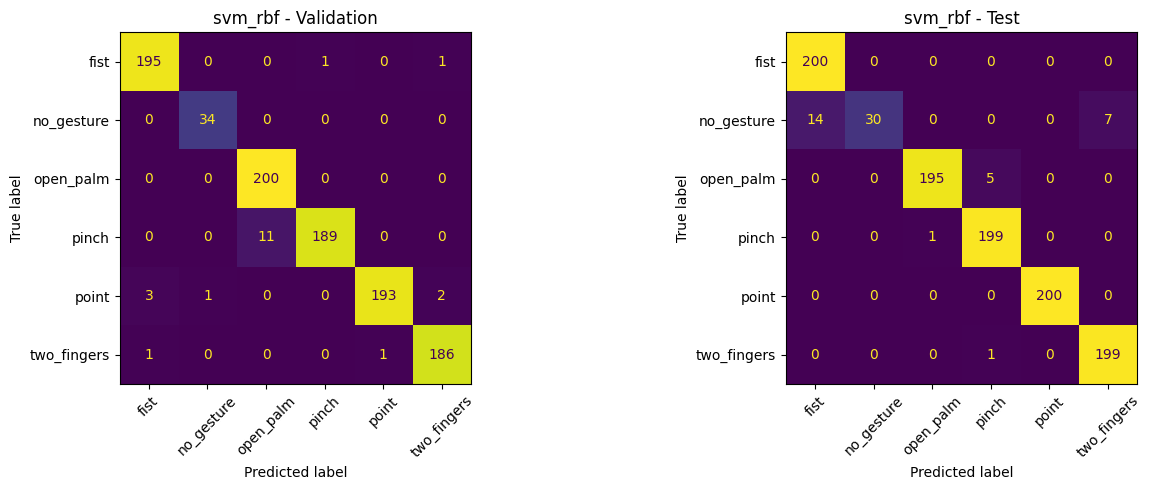

In [14]:
classification_report("svm_rbf")
confusion_matrix("svm_rbf")

### 5.2) Model logistic_regression

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9948    0.9746    0.9846       197
  no_gesture     0.9714    1.0000    0.9855        34
   open_palm     0.9707    0.9950    0.9827       200
       pinch     0.9949    0.9700    0.9823       200
       point     0.9802    0.9950    0.9875       199
 two_fingers     0.9894    0.9894    0.9894       188

    accuracy                         0.9853      1018
   macro avg     0.9836    0.9873    0.9853      1018
weighted avg     0.9854    0.9853    0.9853      1018

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9706    0.9900    0.9802       200
  no_gesture     1.0000    0.5882    0.7407        51
   open_palm     1.0000    0.9800    0.9899       200
       pinch     0.9615    1.0000    0.9804       200
       point     0.9615    1.0000    0.9804       200
 two_fingers     0.9561    0.9800    0.9679       200

    accuracy                         0.9705

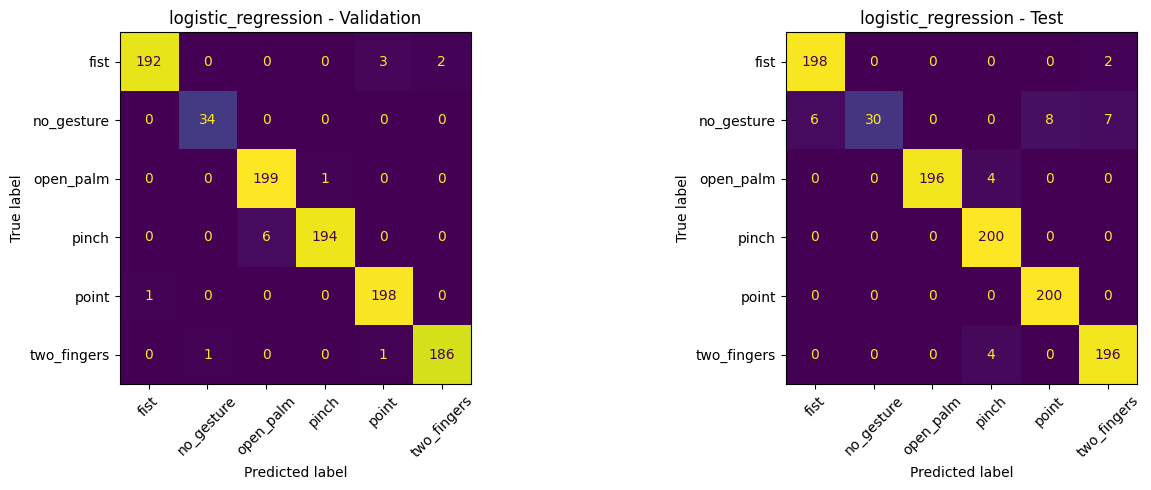

In [15]:
classification_report("logistic_regression")
confusion_matrix("logistic_regression")

### 5.3) Model KNN

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9750    0.9898    0.9824       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.7778    0.8750    0.8235       200
       pinch     0.8621    0.7500    0.8021       200
       point     0.9898    0.9749    0.9823       199
 two_fingers     0.9841    0.9894    0.9867       188

    accuracy                         0.9175      1018
   macro avg     0.9315    0.9298    0.9295      1018
weighted avg     0.9195    0.9175    0.9171      1018

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9104    0.9650    0.9369       200
  no_gesture     1.0000    0.2745    0.4308        51
   open_palm     0.9057    0.9600    0.9320       200
       pinch     0.9005    0.9050    0.9027       200
       point     1.0000    1.0000    1.0000       200
 two_fingers     0.9151    0.9700    0.9417       200

    accuracy                         0.9267

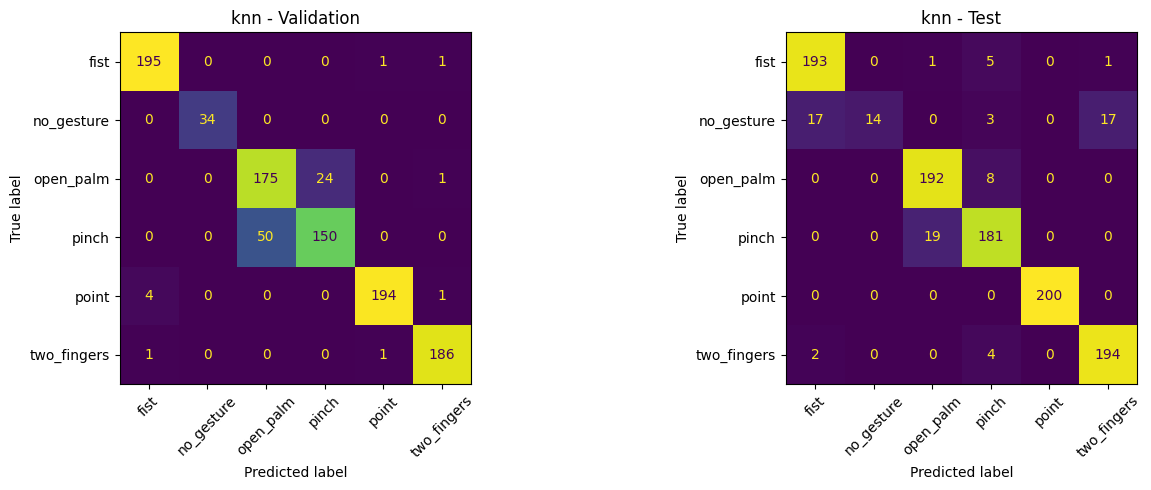

In [16]:
classification_report("knn")
confusion_matrix("knn")

### 5.4) Model random forest

[VALIDATION REPORT]
              precision    recall  f1-score   support

        fist     0.9749    0.9848    0.9798       197
  no_gesture     1.0000    1.0000    1.0000        34
   open_palm     0.9194    0.9700    0.9440       200
       pinch     0.9632    0.9150    0.9385       200
       point     0.9949    0.9749    0.9848       199
 two_fingers     0.9841    0.9894    0.9867       188

    accuracy                         0.9676      1018
   macro avg     0.9727    0.9723    0.9723      1018
weighted avg     0.9681    0.9676    0.9676      1018

[TEST REPORT]
              precision    recall  f1-score   support

        fist     0.9429    0.9900    0.9659       200
  no_gesture     1.0000    0.5294    0.6923        51
   open_palm     0.9948    0.9600    0.9771       200
       pinch     0.9128    0.9950    0.9522       200
       point     1.0000    1.0000    1.0000       200
 two_fingers     0.9310    0.9450    0.9380       200

    accuracy                         0.9562

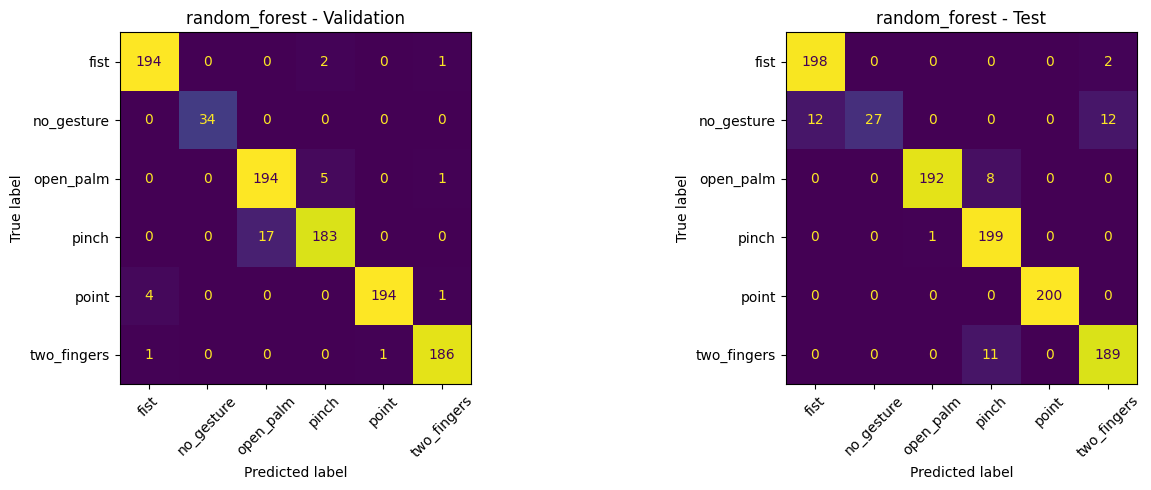

In [17]:
classification_report("random_forest")
confusion_matrix("random_forest")

## 6. Lưu model và báo cáo

In [18]:

print(labels)

['fist', 'no_gesture', 'open_palm', 'pinch', 'point', 'two_fingers']


In [19]:
BEST_MODEL_NAME = summary_df.iloc[0]["model"]

BEST_MODEL_PATH = MODEL_DIR / "static_best_model.joblib"
BEST_META_PATH = MODEL_DIR / "static_best_model_meta.json"

best_model = results[BEST_MODEL_NAME]["model"]

joblib.dump(best_model, BEST_MODEL_PATH)

meta = {
    "best_model": BEST_MODEL_NAME,
    "labels": labels,
    "feature_columns": FEATURE_COLS,
    "feature_dim": len(FEATURE_COLS),
    "val_accuracy": float(results[BEST_MODEL_NAME]["val_acc"]),
    "test_accuracy": float(results[BEST_MODEL_NAME]["test_acc"]),
    "val_macro_f1": float(results[BEST_MODEL_NAME]["val_macro_f1"]),
    "test_macro_f1": float(results[BEST_MODEL_NAME]["test_macro_f1"]),
    "data_files": {
        "train_csv": str(TRAIN_CSV),
        "val_csv": str(VAL_CSV),
        "test_csv": str(TEST_CSV),
    },
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "sklearn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "note": "Best model chosen by highest test_macro_f1, then val_macro_f1, then accuracy."
}

BEST_META_PATH.write_text(
    json.dumps(meta, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Saved model to:", BEST_MODEL_PATH)
print("Saved metadata to:", BEST_META_PATH)
print("Best model name:", BEST_MODEL_NAME)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_best_model.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_best_model_meta.json
Best model name: svm_rbf


In [ ]:
# # Save best final model for deployment
# BEST_MODEL_NAME = 'svm_rbf'
# BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'checkpoints'/ 'static_svm_rbf.joblib'
# BEST_META_PATH = PROJECT_ROOT / 'models' / 'reports' / 'static_svm_rbf_meta.json'

# best_model = results[BEST_MODEL_NAME]['model']

# import joblib
# joblib.dump(best_model, BEST_MODEL_PATH)

# import json
# meta = {
#     'best_model': BEST_MODEL_NAME,
#     'labels': labels,
#     'val_accuracy': float(results[BEST_MODEL_NAME]['val_acc']),
#     'test_accuracy': float(results[BEST_MODEL_NAME]['test_acc']),
#     'feature_columns': FEATURE_COLS,
#     'note': 'Chosen by highest test accuracy and better generalization than logistic_regression'
# }

# BEST_META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')

# print('Saved model to:', BEST_MODEL_PATH)
# print('Saved metadata to:', BEST_META_PATH)

Saved model to: D:\Study\DATN\hand_gesture_windows_control\models\checkpoints\static_svm_rbf.joblib
Saved metadata to: D:\Study\DATN\hand_gesture_windows_control\models\reports\static_svm_rbf_meta.json
